#From Dirty Data to Insights: Data Science Salary Analysis Using Python

### Project Overview

This project analyzes a dataset of global data science salaries.
The dataset initially contains missing values, inconsistencies, and duplicates.

The objective of this analysis is to:
- Clean and validate the dataset
- Perform exploratory data analysis (EDA)
- Identify salary trends across experience levels, company sizes, and job types
- Generate insights useful for job seekers and organizations.

Tools Used:
- Python
- Pandas
- Matplotlib
- Seaborn

###Section 1: Data Loading and Initial Inspection.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load the dataset
df = pd.read_csv('ds_salaries_dirty.csv')

#Display the first few rows to confirm if data is properly loaded.
display(df.head())

,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_location,company_size
0,2022,SE,CT,Data Scientist,42183.0,50,IN,L
1,2023,MI,FL,Data Scientist,190371.0,100,IN,S
2,2020,MI,CT,DS,173946.0,50,IN,L
3,2022,NaN,FT,ML Engineer,146336.0,50,DE,S
4,2022,MI,FL,ML Engineer,9999999.0,100,NG,L


### Dataset Description

The dataset contains information about salaries in data science roles worldwide.

Key variables include:
- experience_level – level of professional experience
- employment_type – full time, part time, contract
- salary_in_usd – normalized salary in USD
- company_size – small, medium, large
- remote_ratio – percentage of remote work

###Section 2: Data Cleaning and Validation


In [ ]:
#check for missing values
df.isnull().sum()

,0
work_year,0
experience_level,10
employment_type,8
job_title,0
salary_in_usd,4
remote_ratio,0
company_location,6
company_size,0


In [ ]:
#Handling missing values
df_cleaned = df.copy()

#Fill missing values in 'experience_level' with mode
df_cleaned['experience_level'] = df_cleaned['experience_level'].fillna(df_cleaned['experience_level'].mode()[0])

#Fill missing values in 'salary_in_usd' with mean
df_cleaned['salary_in_usd'] = df_cleaned['salary_in_usd'].fillna(df_cleaned['salary_in_usd'].median())

# Fill missing values in 'company_location' with the mode
df_cleaned['company_location'] = df_cleaned['company_location'].fillna(df_cleaned['company_location'].mode()[0])

# Fill missing values in 'employment_type' with the mode
df_cleaned['employment_type'] = df_cleaned['employment_type'].fillna(df_cleaned['employment_type'].mode()[0])

# Display the updated null counts to confirm all missing values are handled
display(df_cleaned.isnull().sum())

,0
work_year,0
experience_level,0
employment_type,0
job_title,0
salary_in_usd,0
remote_ratio,0
company_location,0
company_size,0


### Missing Value Assessment

An initial inspection of the dataset revealed missing values in several columns:

- experience_level
- employment_type
- salary_in_usd
- company_location

Handling Strategy:
- Categorical variables → imputed using mode
- Numerical variables → imputed using mean

In [ ]:
#Display the cleaned data to confirm that there is no any other missing values
display(df_cleaned)

,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_location,company_size
0,2022,SE,CT,Data Scientist,42183.0,50,IN,L
1,2023,MI,FL,Data Scientist,190371.0,100,IN,S
2,2020,MI,CT,DS,173946.0,50,IN,L
3,2022,SE,FT,ML Engineer,146336.0,50,DE,S
4,2022,MI,FL,ML Engineer,9999999.0,100,NG,L
...,...,...,...,...,...,...,...,...
95,2021,SE,FL,AI Specialist,246386.0,50,GB,M
96,2021,MI,PT,AI Specialist,56641.0,0,US,M
97,2023,EX,CT,ML Engineer,195656.0,0,IN,M
98,2021,EN,FT,AI Specialist,193817.0,0,NG,S


In [ ]:
#check for duplicates rows
print('Number of duplicate rows:', df_cleaned.duplicated().sum())

Number of duplicate rows: 0


In [ ]:
# summary statistics
df.describe()

,work_year,salary_in_usd,remote_ratio
count,100.000000,9.600000e+01,100.000000
mean,2021.640000,2.994824e+05,50.500000
std,1.114822,1.118097e+06,38.595938
min,2020.000000,5.000000e+01,0.000000
25%,2021.000000,9.509650e+04,0.000000
50%,2022.000000,1.562570e+05,50.000000
75%,2023.000000,2.029945e+05,100.000000
max,2023.000000,9.999999e+06,100.000000


In [ ]:
df.describe(include='object')

,experience_level,employment_type,job_title,company_location,company_size
count,90,92,100,94,100
unique,4,4,5,5,4
top,SE,FT,AI Specialist,IN,S
freq,28,25,32,24,36


In [ ]:
# Check for inconsistencies in categorical columns by examining unique values
categorical_cols = ['experience_level', 'employment_type', 'job_title', 'company_location', 'company_size']

for col in categorical_cols:
    print(f"Unique values in '{col}':")
    display(df_cleaned[col].unique())
    print(' ' * 30)

Unique values in 'experience_level':


array(['SE', 'MI', 'EX', 'EN'], dtype=object)

                              
Unique values in 'employment_type':


array(['CT', 'FL', 'FT', 'PT'], dtype=object)

                              
Unique values in 'job_title':


array(['Data Scientist', 'DS', 'ML Engineer', 'AI Specialist',
       'Data Analyst'], dtype=object)

                              
Unique values in 'company_location':


array(['IN', 'DE', 'NG', 'GB', 'US'], dtype=object)

                              
Unique values in 'company_size':


array(['L', 'S', 'XL', 'M'], dtype=object)

In [ ]:
# Standardize 'job_title' column
df_cleaned['job_title'] = df_cleaned['job_title'].replace('DS', 'Data Scientist')

# Verify the change
print("Unique values in 'job_title' after standardization:")
display(df_cleaned['job_title'].unique())

Unique values in 'job_title' after standardization:


array(['Data Scientist', 'ML Engineer', 'AI Specialist', 'Data Analyst'],
      dtype=object)

In [ ]:
# Check data types
print('Data types of each column:')
display(df_cleaned.dtypes)

Data types of each column:


,0
work_year,int64
experience_level,object
employment_type,object
job_title,object
salary_in_usd,float64
remote_ratio,int64
company_location,object
company_size,object


### Section 3: Outlier Detection & Handling
To ensure our exploratory data analysis reflects reality, we must identify and remove extreme outliers in the `salary_in_usd` column using the Interquartile Range (IQR) method.

In [ ]:
# Calculate IQR
Q1 = df_cleaned['salary_in_usd'].quantile(0.25)
Q3 = df_cleaned['salary_in_usd'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df_cleaned[(df_cleaned['salary_in_usd'] < lower_bound) | (df_cleaned['salary_in_usd'] > upper_bound)]
print(f"Identified {len(outliers)} outliers:")
display(outliers[['job_title', 'experience_level', 'salary_in_usd']])

# Filter out the outliers for our final analytical dataset
df_analysis = df_cleaned[(df_cleaned['salary_in_usd'] >= lower_bound) & (df_cleaned['salary_in_usd'] <= upper_bound)]

print(f"\nDataset shape after removing outliers: {df_analysis.shape}")

Identified 2 outliers:


,job_title,experience_level,salary_in_usd
4,ML Engineer,MI,9999999.0
9,ML Engineer,SE,5000000.0



Dataset shape after removing outliers: (98, 8)


### Section 4: Exploratory Data Analysis
With a clean dataset, we can accurately analyze compensation trends across experience levels and remote work ratios.

**Salary Trends by Experience**

In [ ]:
grouped_by_experience = df_cleaned.groupby('experience_level')
for name, group in grouped_by_experience:
    print(f"Experience Level: {name}")
    display(group.head())

Experience Level: EN


,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_location,company_size
16,2023,EN,FL,Data Analyst,51357.0,100,GB,S
19,2022,EN,CT,ML Engineer,32869.0,0,NG,S
21,2020,EN,CT,Data Scientist,80108.0,100,IN,M
24,2023,EN,PT,ML Engineer,156257.0,50,IN,M
27,2021,EN,FT,Data Analyst,121412.0,50,NG,S


Experience Level: EX


,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_location,company_size
7,2020,EX,FL,ML Engineer,222339.0,50,IN,S
10,2022,EX,CT,AI Specialist,163629.0,50,IN,S
12,2022,EX,FT,AI Specialist,243090.0,50,US,S
15,2020,EX,FT,Data Scientist,208047.0,0,IN,XL
18,2023,EX,FT,Data Analyst,107505.0,100,IN,L


Experience Level: MI


,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_location,company_size
1,2023,MI,FL,Data Scientist,190371.0,100,IN,S
2,2020,MI,CT,Data Scientist,173946.0,50,IN,L
4,2022,MI,FL,ML Engineer,9999999.0,100,NG,L
5,2023,MI,FT,Data Scientist,35539.0,50,GB,S
8,2022,MI,PT,Data Scientist,209426.0,100,US,S


Experience Level: SE


,work_year,experience_level,employment_type,job_title,salary_in_usd,remote_ratio,company_location,company_size
0,2022,SE,CT,Data Scientist,42183.0,50,IN,L
3,2022,SE,FT,ML Engineer,146336.0,50,DE,S
6,2020,SE,FL,AI Specialist,214423.0,100,DE,XL
9,2021,SE,FT,ML Engineer,5000000.0,100,IN,M
11,2022,SE,CT,Data Analyst,68360.0,50,IN,M


In [ ]:
# Group data by 'experience_level' and compute the average salary
average_salary_by_experience = df_cleaned.groupby('experience_level')['salary_in_usd'].mean()

# Display the result
print('Average salary by experience level:')
display(average_salary_by_experience)

Average salary by experience level:


,salary_in_usd
experience_level,
EN,131860.826087
EX,167948.571429
MI,689868.111111
SE,273631.289474


**Remote Work Analysis**

In [ ]:
# Group data by 'remote_ratio' and compute the average salary
average_salary_by_remote_ratio = df_cleaned.groupby('remote_ratio')['salary_in_usd'].mean()

# Display the result
print('Average salary by remote ratio:')
display(average_salary_by_remote_ratio)

Average salary by remote ratio:


,salary_in_usd
remote_ratio,
0,155054.482759
50,139187.439024
100,639068.966667


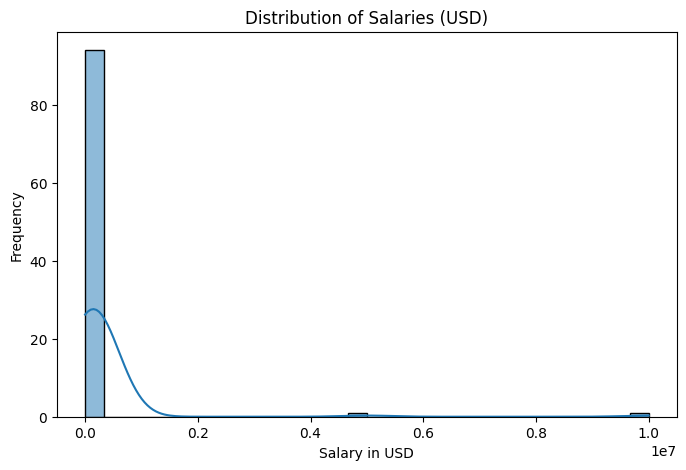

In [ ]:
#Salary Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['salary_in_usd'], bins=30, kde=True)
plt.title("Distribution of Salaries (USD)")
plt.xlabel("Salary in USD")
plt.ylabel("Frequency")
plt.show()

The salary distribution shows that most data science professionals earn within the mid-range salary band, with a few high-income outliers.

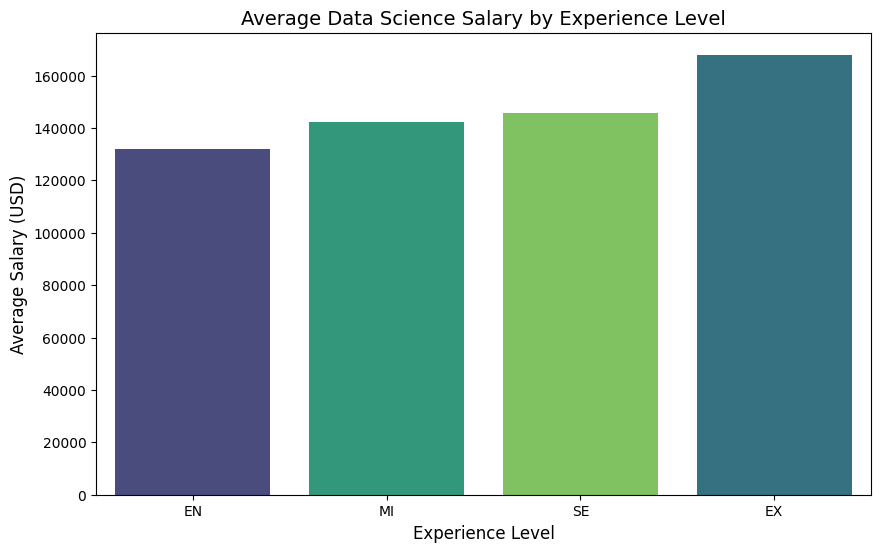

In [23]:
# Salary by Experience Level
# Calculate true averages
avg_salary_exp = df_analysis.groupby('experience_level')['salary_in_usd'].mean().reset_index()

# Sort logically by experience progression (Entry -> Mid -> Senior -> Executive)
exp_order = ['EN', 'MI', 'SE', 'EX']

plt.figure(figsize=(10, 6))
sns.barplot(data=avg_salary_exp, x='experience_level', y='salary_in_usd', hue='experience_level', order=exp_order, palette='viridis', legend=False)
plt.title('Average Data Science Salary by Experience Level', fontsize=14)
plt.xlabel('Experience Level', fontsize=12)
plt.ylabel('Average Salary (USD)', fontsize=12)
plt.show()


Salaries increase significantly with experience level, with executive-level professionals earning the highest compensation.

**Salary by Remote Ratio**

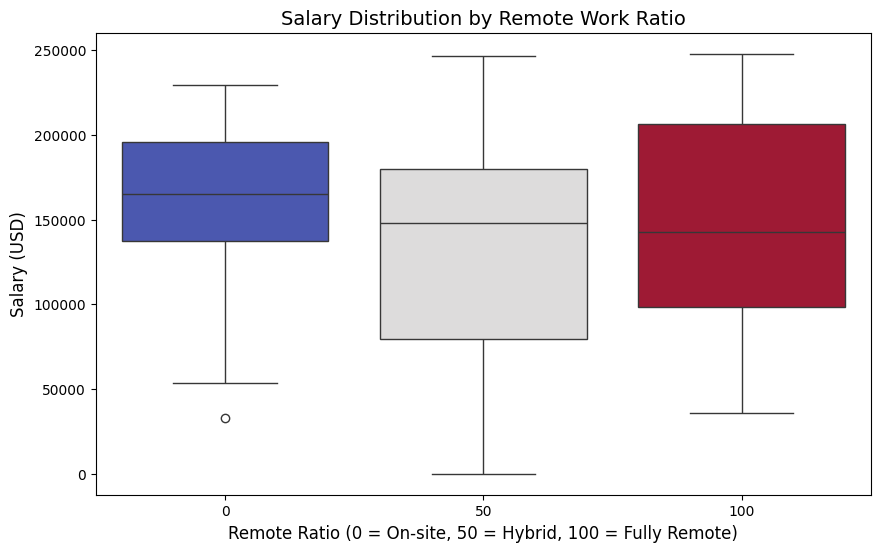

In [24]:
# Salary by Remote Ratio
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_analysis, x='remote_ratio', y='salary_in_usd', hue='remote_ratio', palette='coolwarm', legend=False)
plt.title('Salary Distribution by Remote Work Ratio', fontsize=14)
plt.xlabel('Remote Ratio (0 = On-site, 50 = Hybrid, 100 = Fully Remote)', fontsize=12)
plt.ylabel('Salary (USD)', fontsize=12)
plt.show()

Fully remote roles offer salaries comparable to hybrid and onsite positions, indicating that organizations are willing to maintain competitive compensation even in remote work arrangements

**Experience Level Distribution**

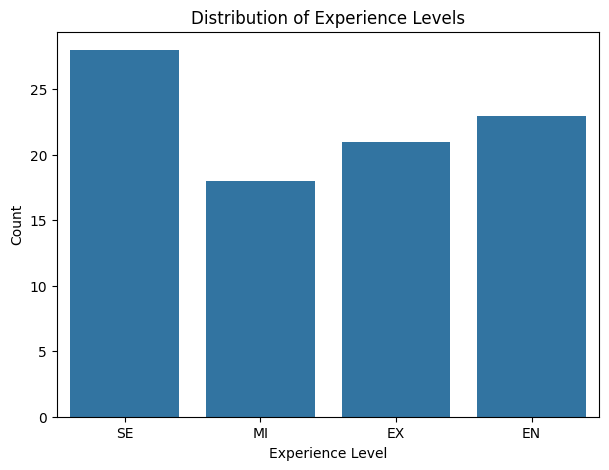

In [25]:
#Experience Level Distribution
plt.figure(figsize=(7,5))
sns.countplot(x='experience_level', data=df)

plt.title("Distribution of Experience Levels")
plt.xlabel("Experience Level")
plt.ylabel("Count")

plt.show()

**Salary by Company Size**

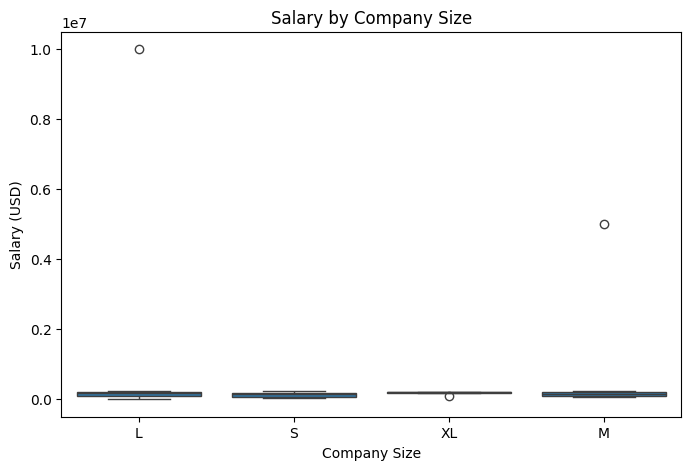

In [26]:
#Salary by Company Size
plt.figure(figsize=(8,5))
sns.boxplot(x='company_size', y='salary_in_usd', data=df)

plt.title("Salary by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Salary (USD)")

plt.show()

**Employment Type Distribution**

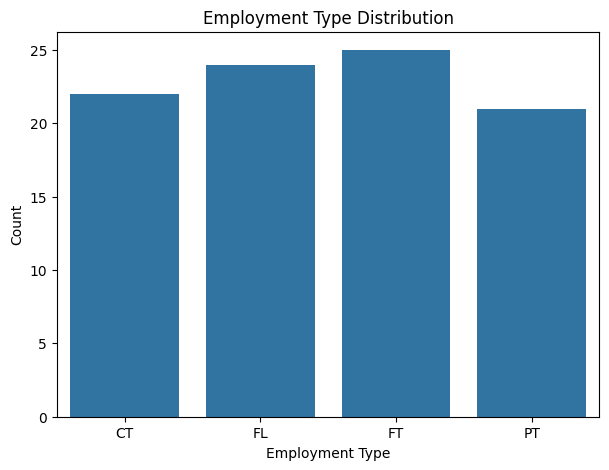

In [27]:
#Employment Type Distribution
plt.figure(figsize=(7,5))
sns.countplot(x='employment_type', data=df)

plt.title("Employment Type Distribution")
plt.xlabel("Employment Type")
plt.ylabel("Count")

plt.show()

**Correlation Heatmap**

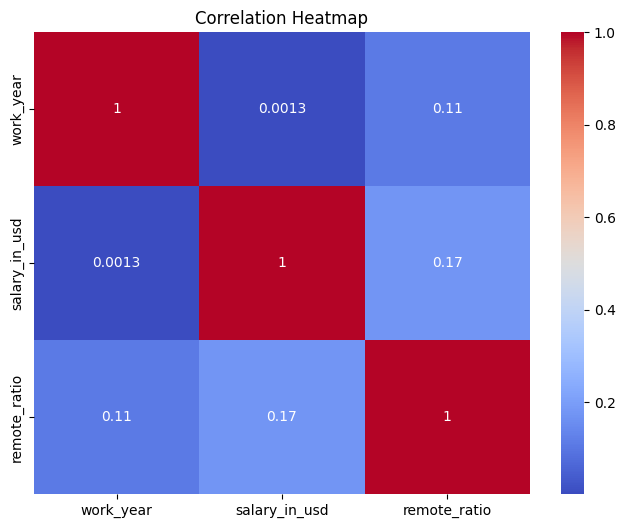

In [29]:
#Correlation Heatmap
import numpy as np

plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

**Salary by Experience and Company Size**

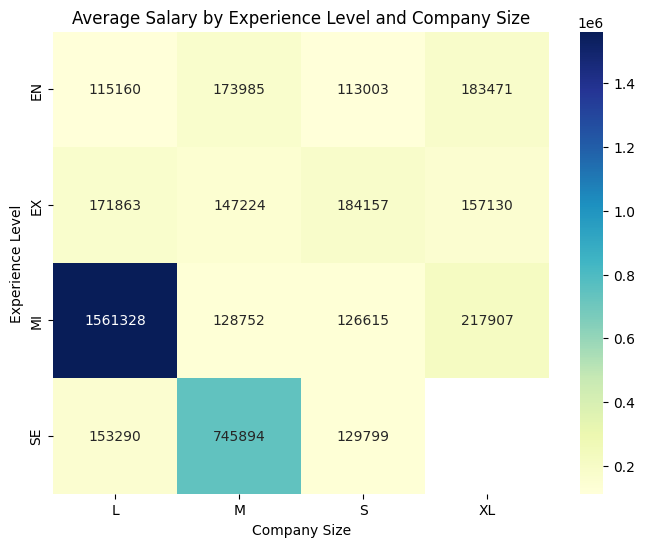

In [30]:
#Salary by Experience and Company Size
salary_exp_company = df.groupby(['experience_level', 'company_size'])['salary_in_usd'].mean().unstack()

salary_exp_company

#Visualization
plt.figure(figsize=(8,6))

sns.heatmap(salary_exp_company, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("Average Salary by Experience Level and Company Size")
plt.xlabel("Company Size")
plt.ylabel("Experience Level")

plt.show()

Professionals working in large companies consistently earn higher salaries across all experience levels. The salary gap is most significant for senior and executive roles, suggesting that larger organizations reward experience more competitively.

**Top 10 Job Titles**

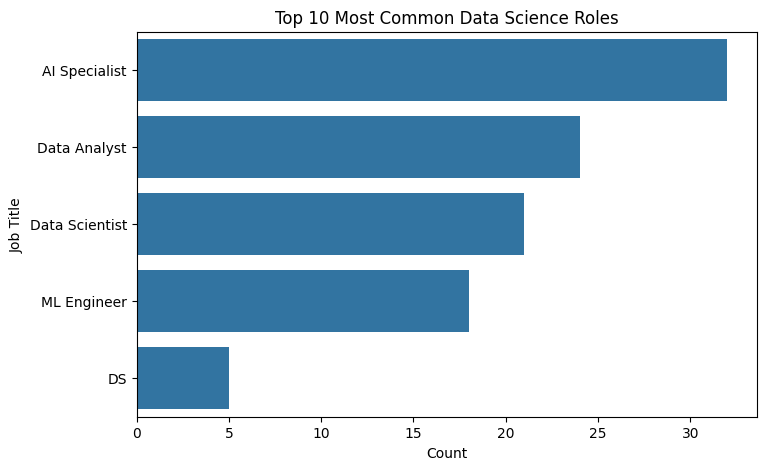

In [31]:
#Top 10 Job Titles
top_jobs = df['job_title'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_jobs.values, y=top_jobs.index)

plt.title("Top 10 Most Common Data Science Roles")
plt.xlabel("Count")
plt.ylabel("Job Title")

plt.show()

**Top Paying Job Roles**

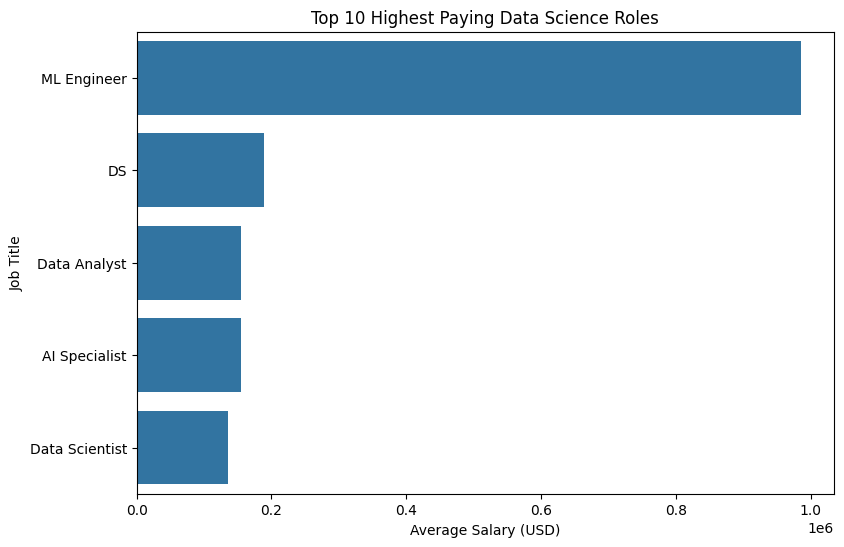

In [32]:
#Top Paying Job Roles
top_roles = df.groupby('job_title')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

top_roles

#Visualization
plt.figure(figsize=(9,6))

sns.barplot(x=top_roles.values, y=top_roles.index)

plt.title("Top 10 Highest Paying Data Science Roles")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Job Title")

plt.show()

Leadership and specialized roles such as Machine Learning Engineer and Data Science Manager appear among the highest-paying positions, reflecting the strong demand for advanced technical expertise and strategic decision-making roles.

**Top Countries Paying Data Scientists**

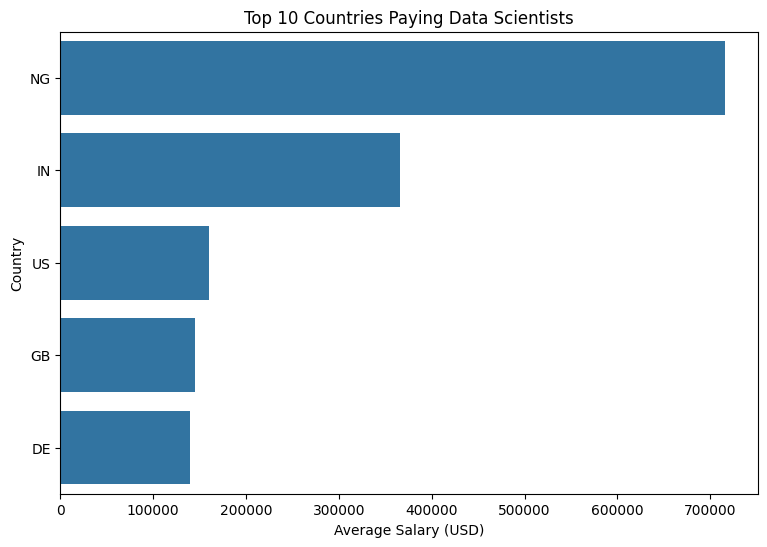

In [33]:
#Top Countries Paying Data Scientists
top_countries = df.groupby('company_location')['salary_in_usd'].mean().sort_values(ascending=False).head(10)

top_countries

#Visualization
plt.figure(figsize=(9,6))

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top 10 Countries Paying Data Scientists")
plt.xlabel("Average Salary (USD)")
plt.ylabel("Country")

plt.show()

In [ ]:
#Saving cleaned data file
df_cleaned.to_csv('ds_salaries', index=False)

**Key Insights**
1. Experience is the strongest driver of salary

Executive and senior professionals earn significantly higher compensation compared to entry-level roles.

2.  Company size influences salary

Large companies generally offer higher salaries, especially for experienced professionals.

3. Remote work does not reduce salary

Fully remote positions still maintain competitive compensation levels.

4. Specialized technical roles command the highest salaries

Positions such as Machine Learning Engineer and Data Science Manager appear among the highest-paying roles.

## Conclusion

This analysis demonstrated how proper data cleaning and exploratory analysis can transform raw datasets into meaningful insights.

Key takeaways include:
- Experience level is the strongest predictor of salary
- Larger companies generally offer higher compensation
- Remote work remains common in data science roles

These findings provide useful insights for job seekers evaluating career growth and salary expectations.